In [ ]:
from mlx.nn import ReLU
import mlx.data as dx
import mlx.core as mx

from src.config import OptimizerConfig, EncoderConfig
from src.processing import get_all_dataset, get_trades_tokenizer, get_volatility_seq, save_tokenizer, load_tokenizer, get_num_embedding, compute_df_feature, encode_df_feature

CATEGORIAL_COLUMNS = ["TradeType", "MifidInstrumentID", "MmtMarketMechanism", "MmtTradingMode", "MmtAlgorithmicIndicator", "Venue"]
CONTINUOUS_COLUMNS = ["delta_event_ts", "log_volume", "norm_volume", "time_cos", "time_sin"]
SEQUENCE_SIZE = 60
VOLATILITY_SCALE = 10 
SAVE_DIR = "weight"
ENCODER_DEPTH = 4
EMBEDDING_DIM = [4, 8, 4, 4, 4, 4] # 8 for InstrumentID to get better clustering

dataset = get_all_dataset(dir="equities_trade")

print(f"👾 Load {len(dataset)} trades")
print(dataset.tail(1))

tokenizer = load_tokenizer(path="tokenizer.json") 

dataset = encode_df_feature(dataset, tokenizer)
dataset = compute_df_feature(dataset, norm_log_return_window=10, norm_volume_window=10)


encoder_config = EncoderConfig(num_continuous_col=len(CONTINUOUS_COLUMNS), 
                              depth=ENCODER_DEPTH,
                              embedding_dim=EMBEDDING_DIM,
                              num_embedding=get_num_embedding(dataset, CATEGORIAL_COLUMNS),
                              categorical_col=CATEGORIAL_COLUMNS)

dataset


Found 6 files in directory
👾 Load 6427974 trades
shape: (1, 12)
┌────────────┬────────────┬────────────┬───────────┬───┬───────────┬───────────┬───────────┬───────┐
│ EventTime  ┆ TradingDat ┆ Publicatio ┆ MifidInst ┆ … ┆ MmtMarket ┆ MmtTradin ┆ MmtAlgori ┆ Venue │
│ ---        ┆ eTime      ┆ nDateTime  ┆ rumentID  ┆   ┆ Mechanism ┆ gMode     ┆ thmicIndi ┆ ---   │
│ str        ┆ ---        ┆ ---        ┆ ---       ┆   ┆ ---       ┆ ---       ┆ cator     ┆ str   │
│            ┆ str        ┆ str        ┆ str       ┆   ┆ str       ┆ str       ┆ ---       ┆       │
│            ┆            ┆            ┆           ┆   ┆           ┆           ┆ str       ┆       │
╞════════════╪════════════╪════════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════╡
│ 2026-03-12 ┆ 2026-03-12 ┆ 2026-03-12 ┆ FR001400A ┆ … ┆ 4         ┆ 5         ┆ human     ┆ XPAR  │
│ T16:55:52. ┆ T16:55:23. ┆ T16:55:53. ┆ HX6       ┆   ┆           ┆           ┆           ┆       │
│ 000000000Z ┆ 000000Z    ┆

MifidInstrumentID,delta_event_ts,delta_trading_ts,delta_publication_ts,log_return,log_volume,norm_log_return,norm_volume,TradeType,MmtMarketMechanism,MmtTradingMode,MmtAlgorithmicIndicator,Venue,event_ts
i32,list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[i32],list[i32],list[i32],list[i32],list[i32],list[i64]
155,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[0.693147, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[0.693147, 3.295837, … 0.693147]","[0.0, 0.0, … 0.0]","[-2.293862, 0.35991, … -2.770051]","[4, 4, … 4]","[0, 0, … 0]","[4, 4, … 0]","[1, 1, … 0]","[1, 1, … 1]","[1773907211220077, 1773907211220077, … 1773333320327694]"
411,"[6.549651, 20.890775, … 22.919162]","[6.55108, 20.890775, … 22.919162]","[6.55108, 20.890775, … 22.919162]","[-0.000102, -0.002541, … 0.002554]","[3.044522, 3.044522, … 0.693147]","[-0.000091, -0.002277, … 0.003063]","[0.728692, 0.654499, … -1.922133]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 1]","[0, 0, … 1]","[1, 1, … 1]","[1773994801714034, 1773995984069704, … 1773332993077764]"
268,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.693147]","[0.0, 0.0, … 0.0]","[2.484907, 1.791759, … 0.693147]","[0.0, 0.0, … 0.0]","[-0.025452, -0.571966, … -1.667539]","[4, 4, … 4]","[0, 0, … 0]","[4, 4, … 0]","[0, 0, … 0]","[1, 1, … 1]","[1773907218281301, 1773907218281301, … 1773333306343906]"
134,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[5.181784, 5.068904, … 2.772589]","[0.0, 0.0, … 0.00056]","[1.204476, 0.654021, … -2.59014]","[4, 4, … 4]","[0, 0, … 0]","[4, 4, … 0]","[0, 0, … 0]","[2, 2, … 2]","[1773907212462132, 1773907212462132, … 1773333322144008]"
280,"[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[4.454347, 4.828314, … 2.890372]","[0.0, 0.0, … 0.0]","[0.002121, 0.419006, … -1.515003]","[4, 4, … 4]","[0, 0, … 0]","[0, 0, … 4]","[0, 0, … 0]","[3, 3, … 3]","[1773934227646792, 1773934227646792, … 1773311404774790]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
518,[],[],[],[],[],[],[],[],[],[],[],[],[]
250,"[0.0, 19.502713, … 21.655673]","[0.0, 19.502713, … 21.655554]","[0.0, 19.502712, … 21.655554]","[0.0, 0.0, … 0.0]","[7.824446, 6.214608, … 1.098612]","[0.001242, 0.000995, … 0.0]","[2.318572, 0.775209, … -3.580909]","[4, 4, … 4]","[0, 0, … 0]","[1, 1, … 0]","[0, 0, … 0]","[2, 2, … 2]","[1773910155599836, 1773910450666726, … 1773333307143805]"
113,"[NaN, 13.165425, … 0.0]","[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[0.0, 0.0, … 0.0]","[9.313619, 7.635787, … 7.245655]","[-0.01876, -0.023639, … 0.0]","[1.740752, -0.009783, … 0.42483]","[4, 4, … 4]","[0, 0, … 0]","[4, 4, … 0]","[0, 1, … 1]","[3, 3, … 3]","[1773657020910717, 1773657021432717, … 1773329410446469]"


====== Volatility Model =====

100%|██████████| 598/598 [01:11<00:00,  8.31it/s]


Target mean -->  0.90912926 +/- 2.416408
MLX Buffer size --> 6362775
MLX train buffer init in  24.117125034332275
MLX test buffer init in  16.394211769104004
EPOCH 1 --- 


4350it [55:57,  1.30it/s]
1865it [03:42,  8.39it/s]


TRAIN LOSS 2.149597929110474 ||| TEST LOSS 1.4264863715286857
EPOCH 2 --- 


4350it [57:54,  1.25it/s]
1865it [03:46,  8.25it/s]


...

TRAIN LOSS 2.1508601706493824 ||| TEST LOSS 1.4293951550757258
EPOCH 4 --- 


4350it [55:30,  1.31it/s]
1865it [03:48,  8.16it/s]


TRAIN LOSS 2.1467212342887083 ||| TEST LOSS 1.4267564314108432
EPOCH 5 --- 


4350it [54:57,  1.32it/s]
1865it [03:44,  8.32it/s]


TRAIN LOSS 2.152524073195181 ||| TEST LOSS 1.4277232853784656


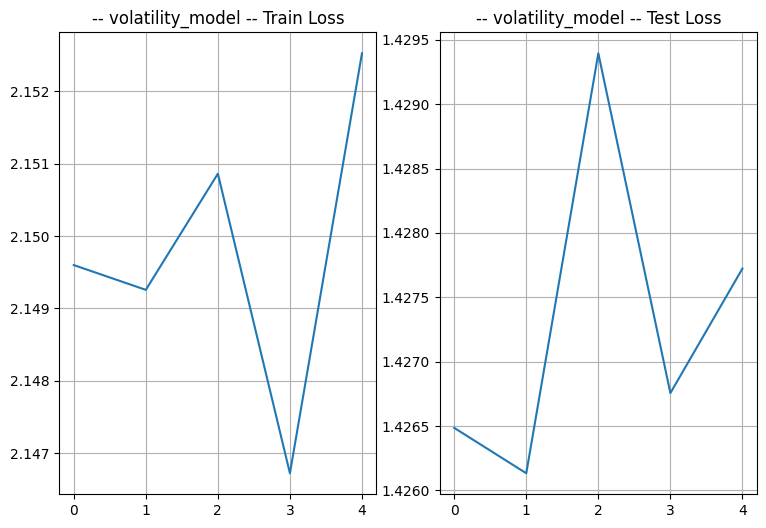

In [ ]:
from src.trainer import VolatilityTrainer
from src.volatility_nn import VolatilityPredictor
from src.config import VolatilityConfig


volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)

optimizer_config = OptimizerConfig(optimizer_name="adam", lr=1e-4)
volatility_model = VolatilityPredictor(encoder_config=encoder_config, volatility_config=volatility_config)
mx.eval(volatility_model.parameters())


sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
print(f"MLX Buffer size --> {len(buffer)}")

trainer = VolatilityTrainer(model=volatility_model, 
                            optim_config=optimizer_config, 
                            buffer=buffer, 
                            categorical_columns=CATEGORIAL_COLUMNS, 
                            train_size=0.7,
                            batch_size=1024,
                            scale= VOLATILITY_SCALE)

trainer.epoch(n_epoch=5, 
              save_dir=SAVE_DIR, 
              model_name="volatility_model", 
              plot_chart=True)



100%|██████████| 598/598 [01:25<00:00,  7.02it/s]


Target mean -->  0.9091283 +/- 2.4164064
references quantile --> [0.25, 0.5, 0.75, 0.9]
Target quantile --> [0.38796467 0.55826437 0.85665661 1.62671494]


100%|██████████| 318139/318139 [13:35<00:00, 390.34it/s]


8 <_top k
View of topk -> shape: (8, 2)
┌─────────┬──────────┐
│ isin_id ┆ score    │
│ ---     ┆ ---      │
│ i64     ┆ f64      │
╞═════════╪══════════╡
│ 378     ┆ 0.964892 │
│ 98      ┆ 0.943677 │
│ 250     ┆ 0.942478 │
│ 116     ┆ 0.938968 │
│ 104     ┆ 0.932932 │
│ 524     ┆ 0.929835 │
│ 491     ┆ 0.925003 │
│ 262     ┆ 0.911155 │
└─────────┴──────────┘


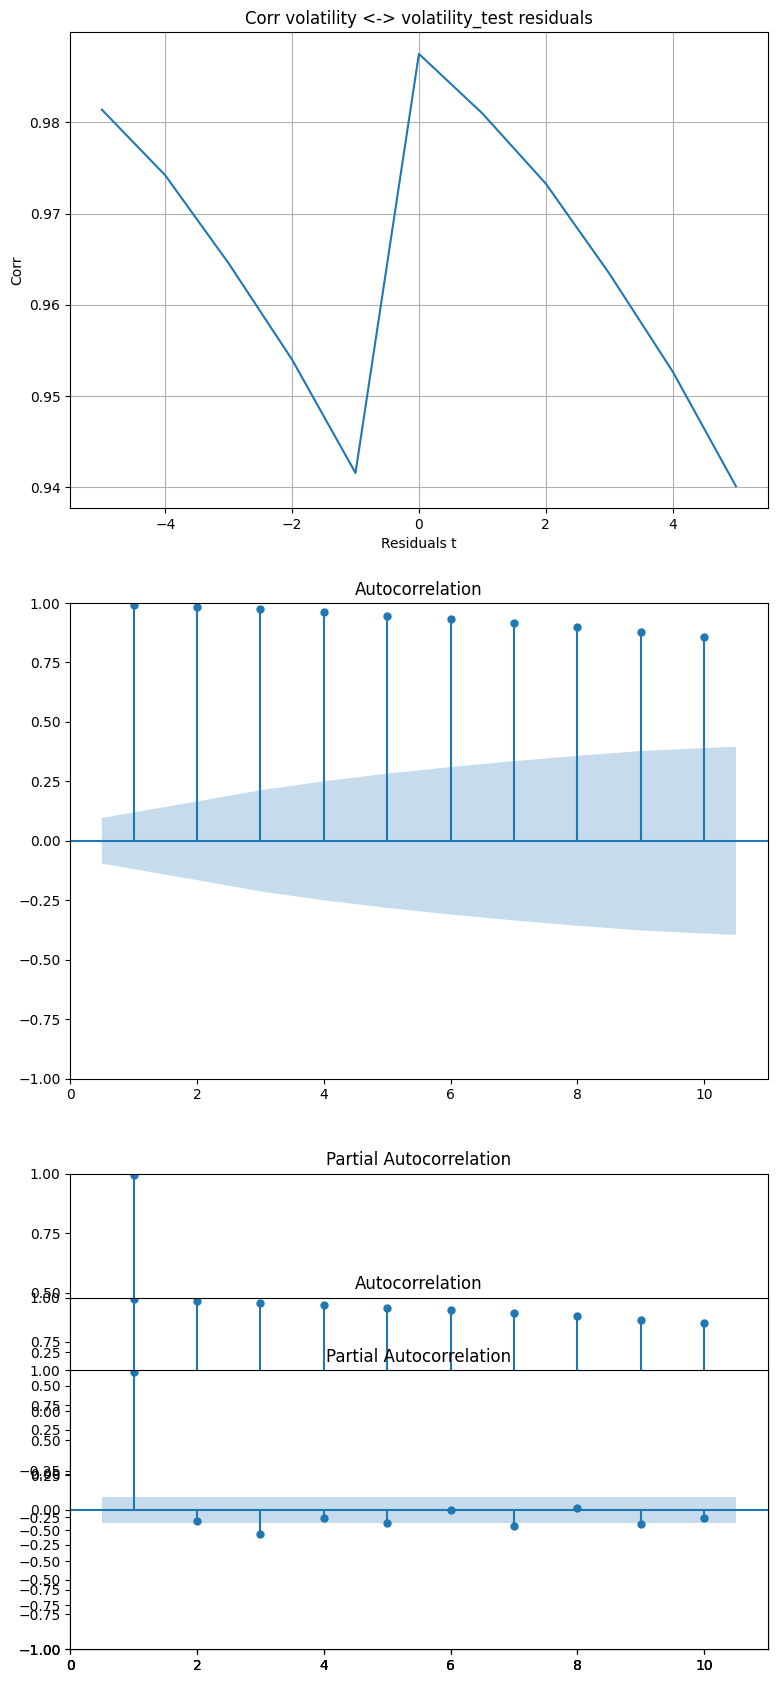

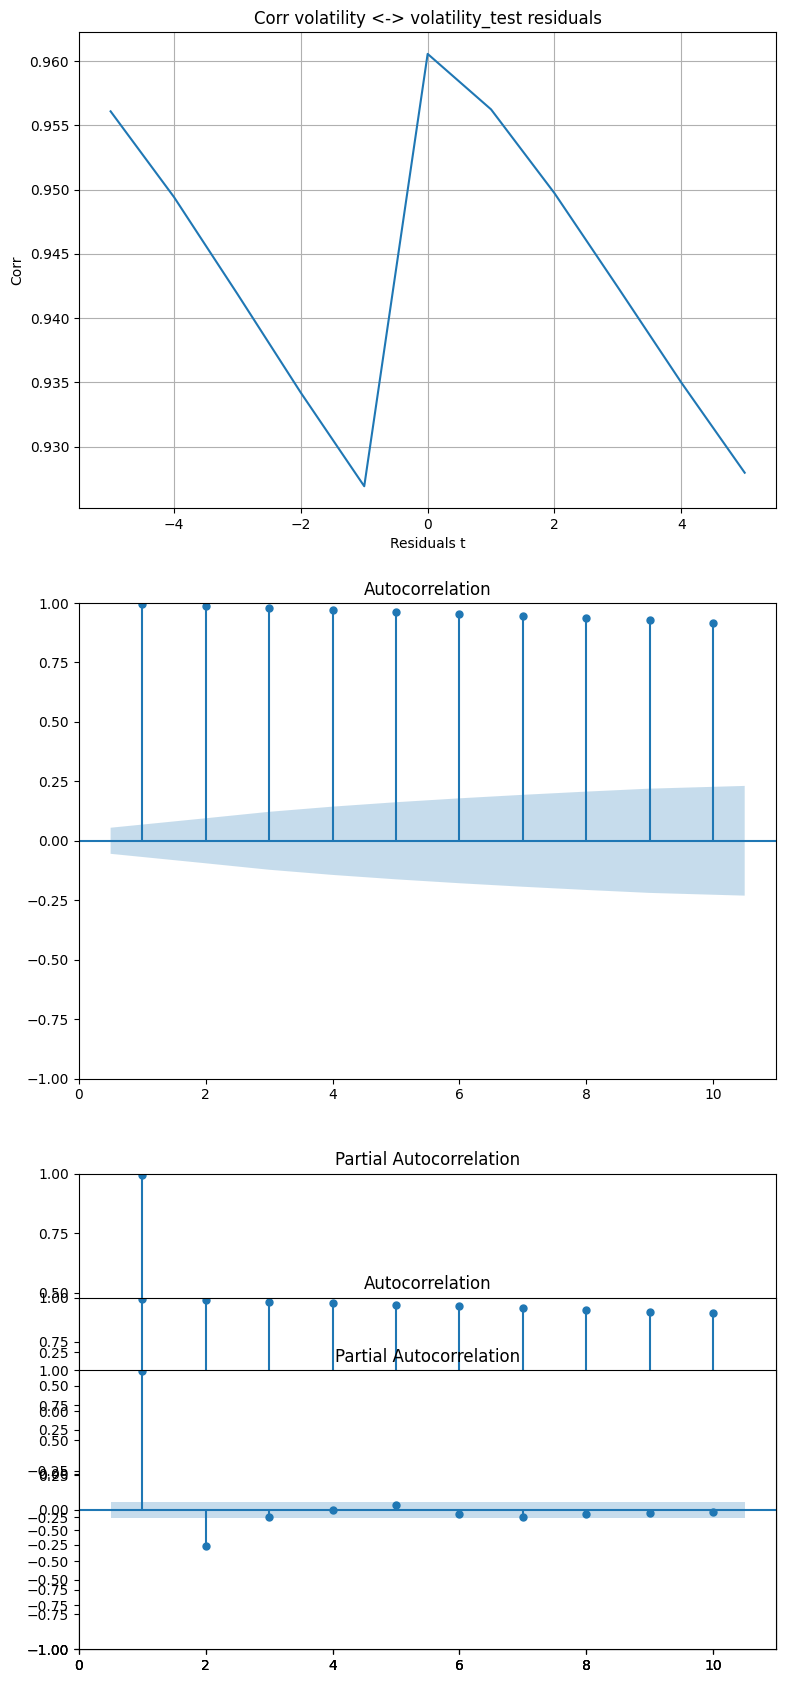

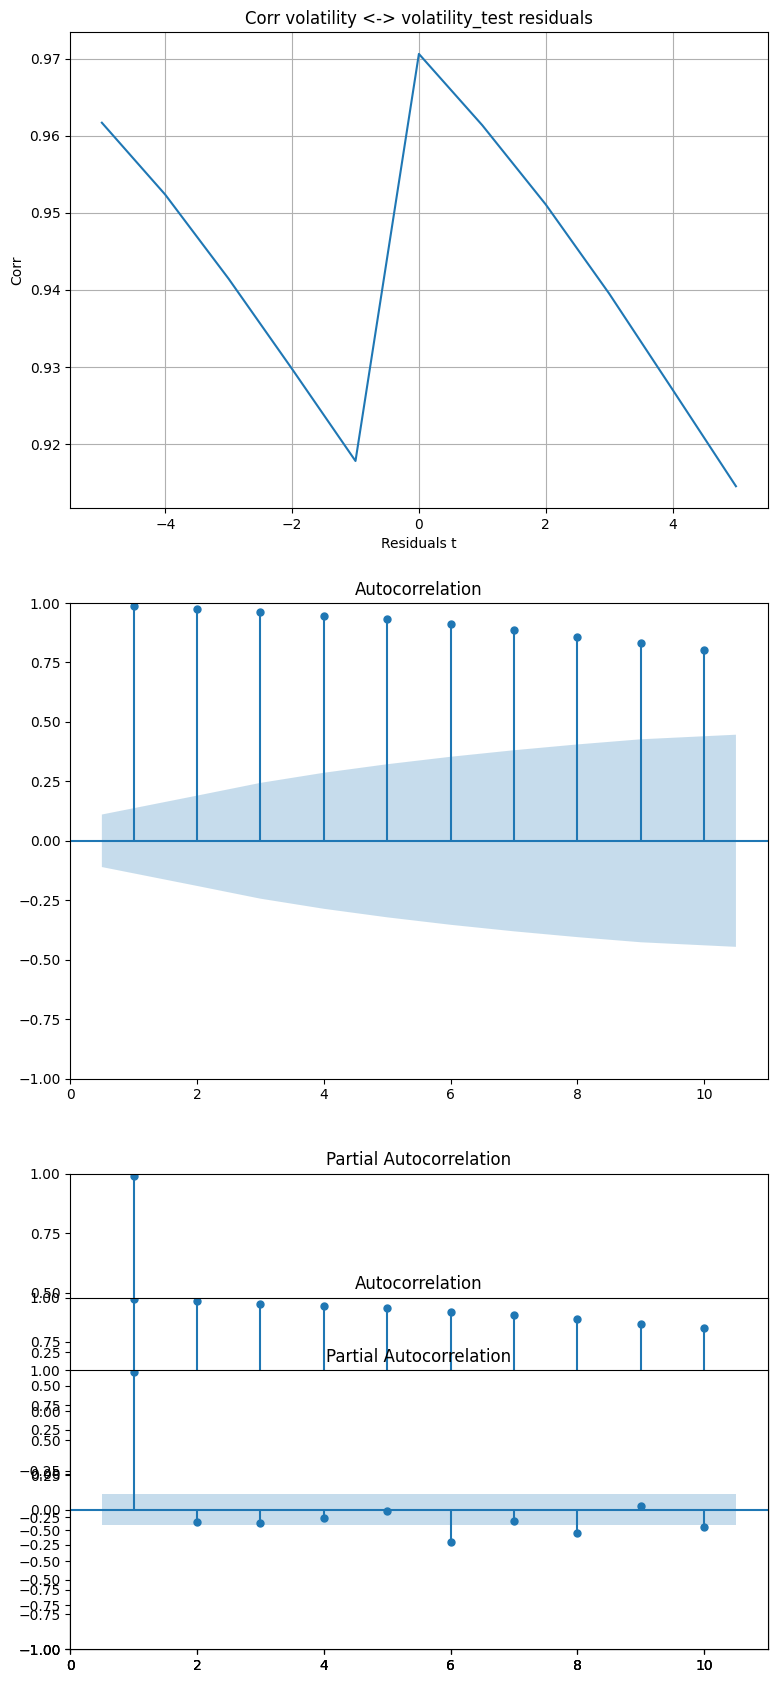

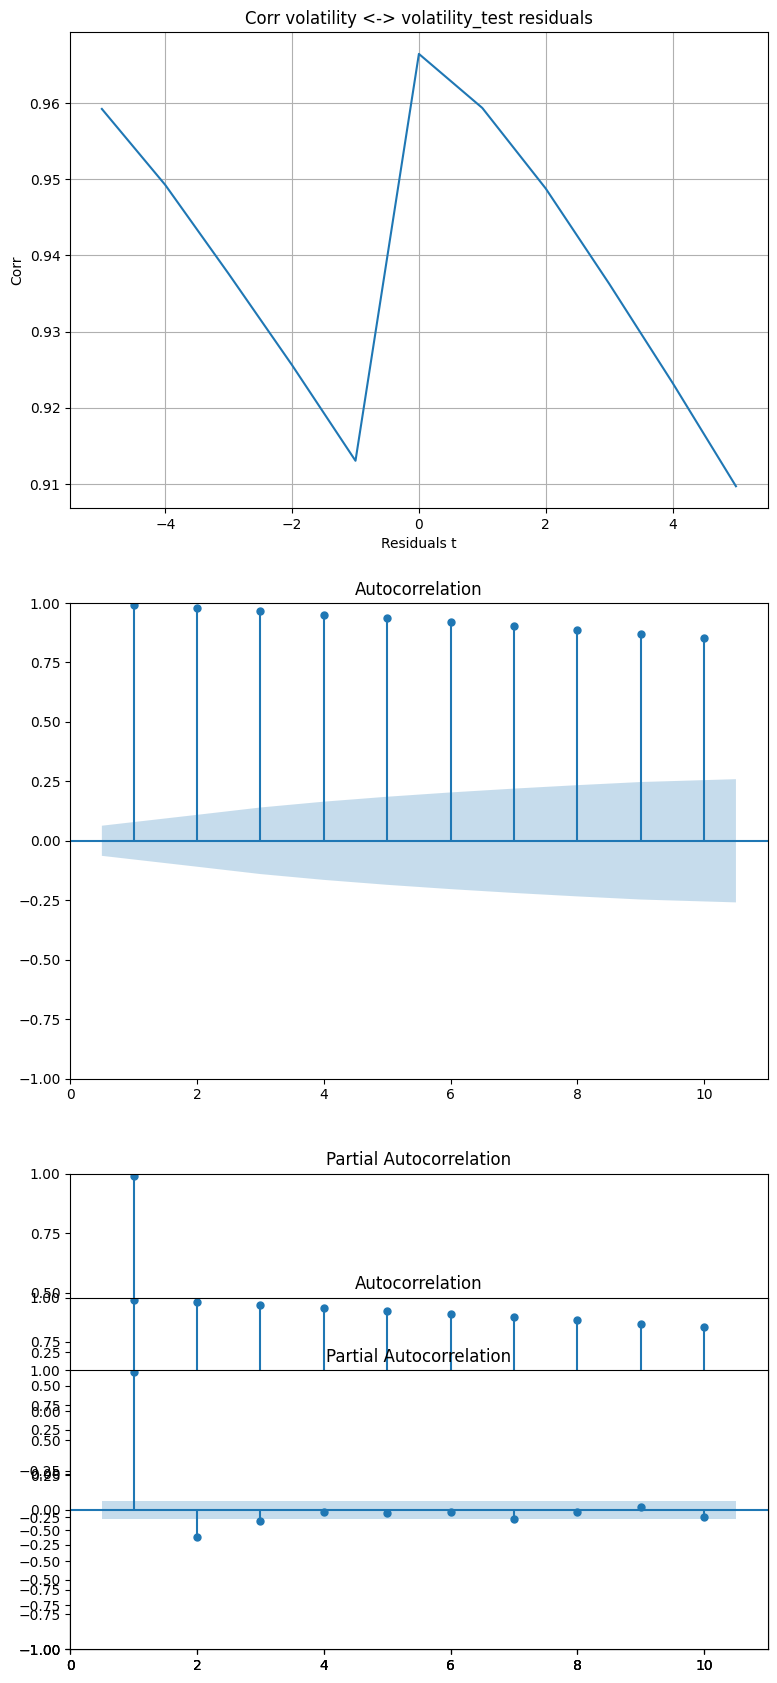

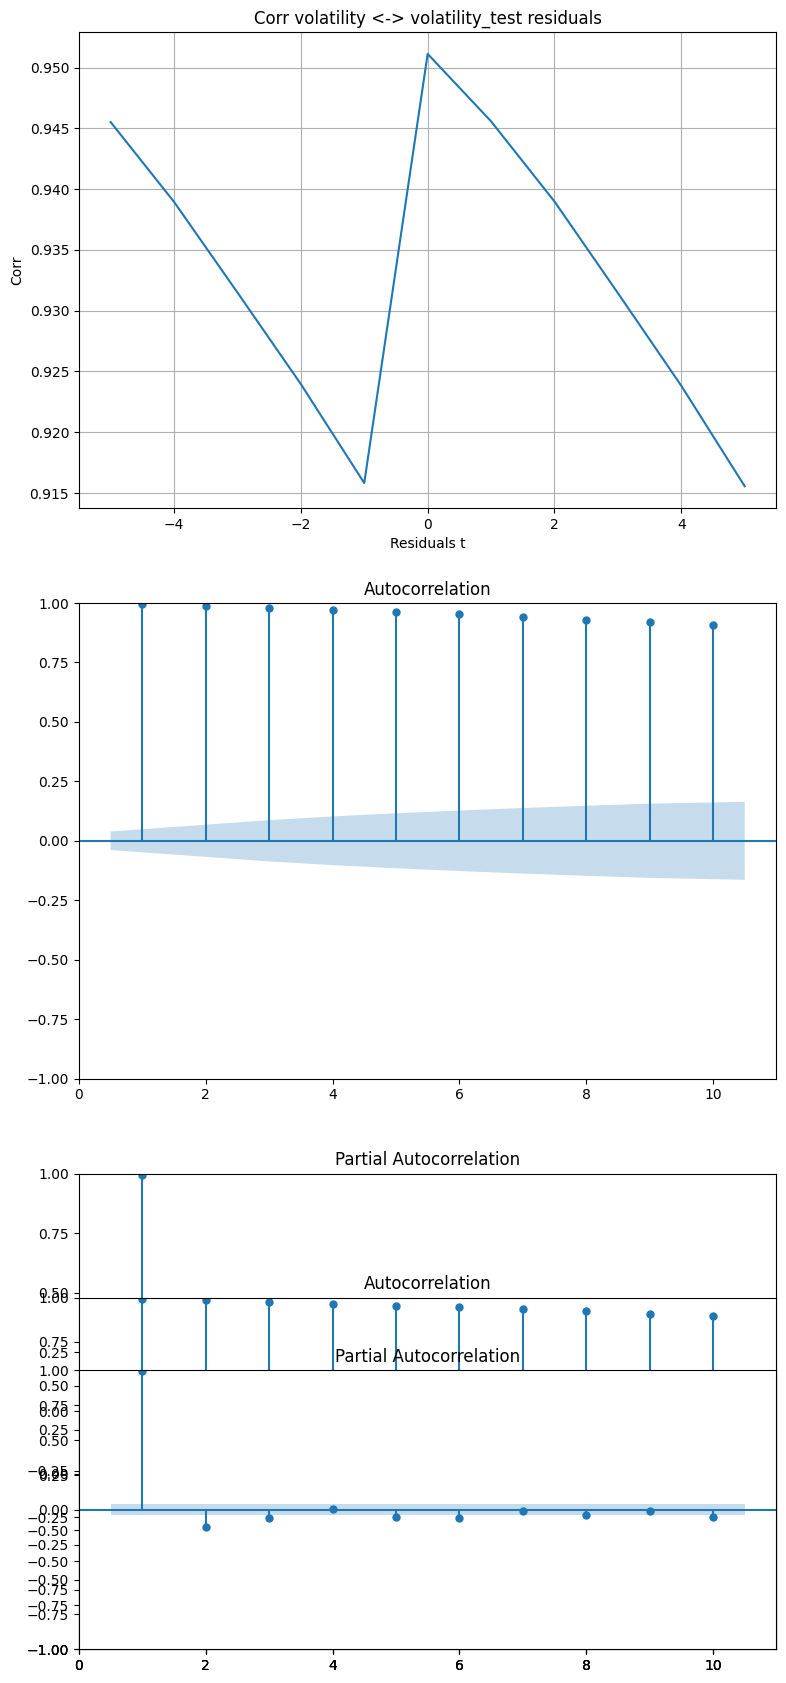

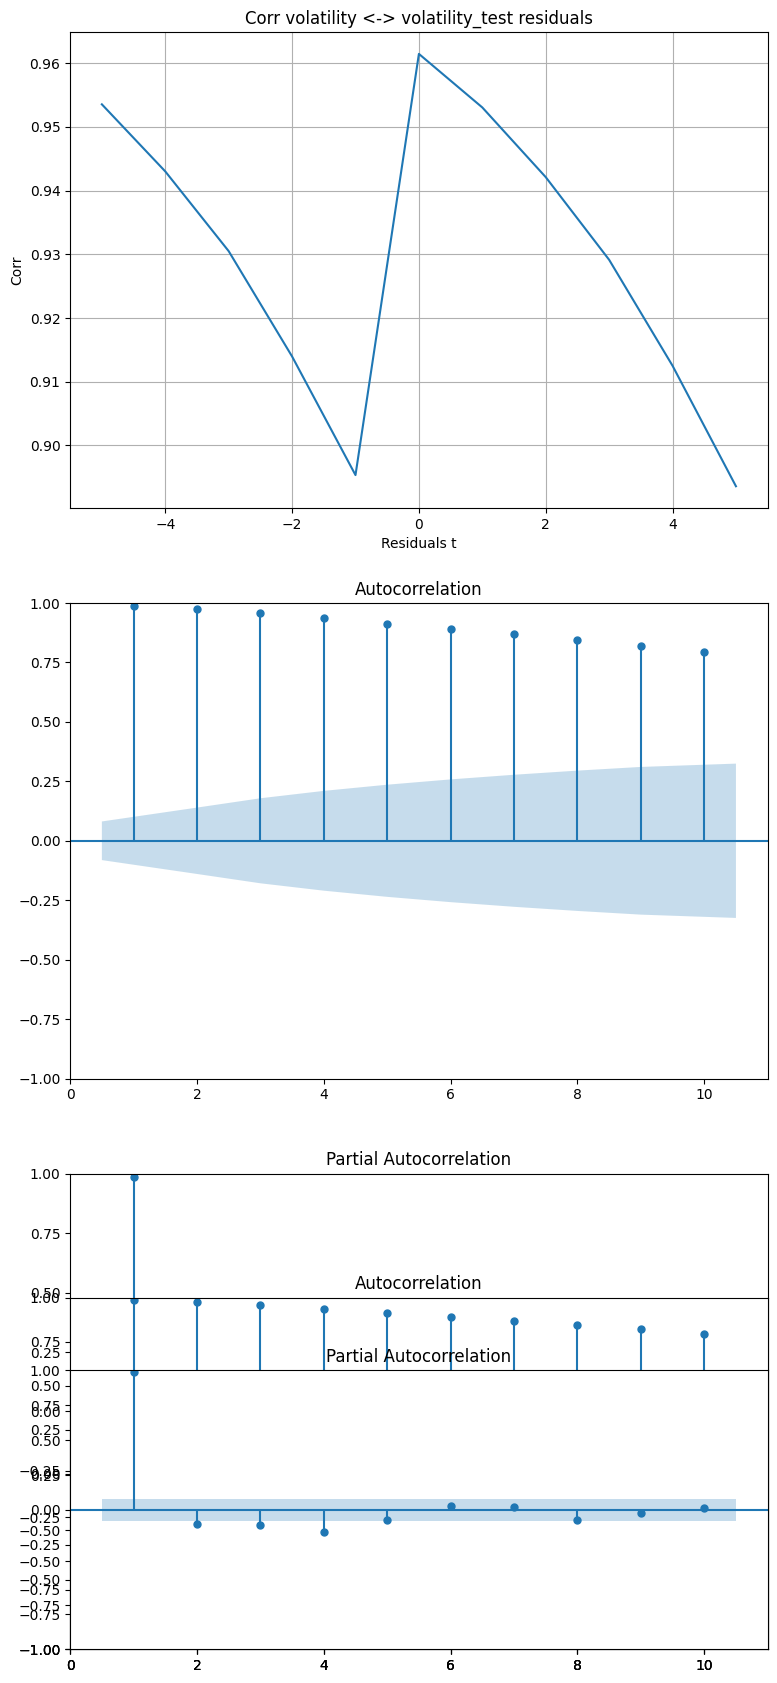

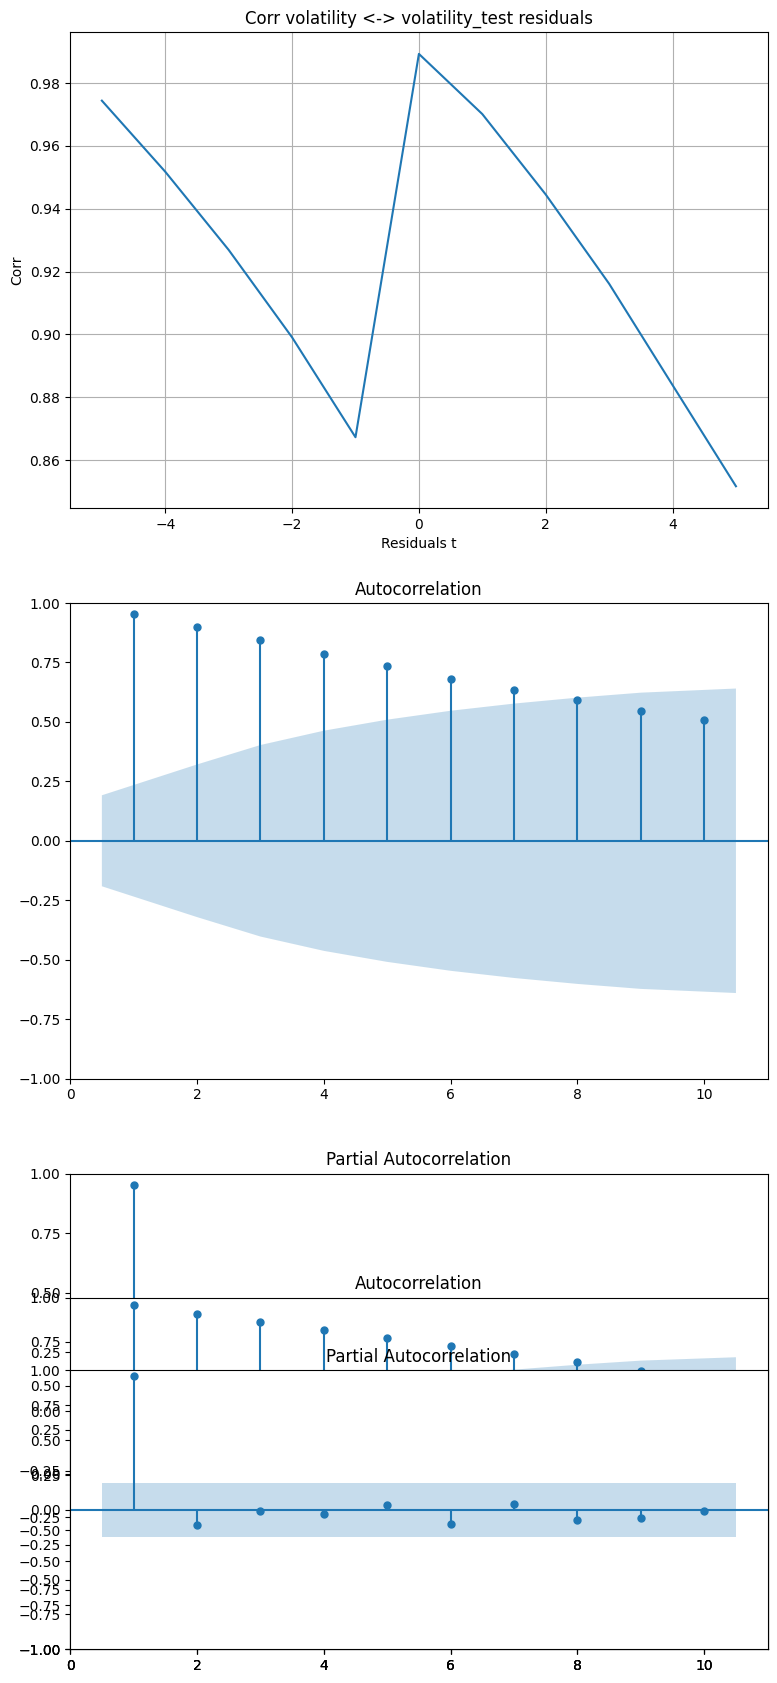

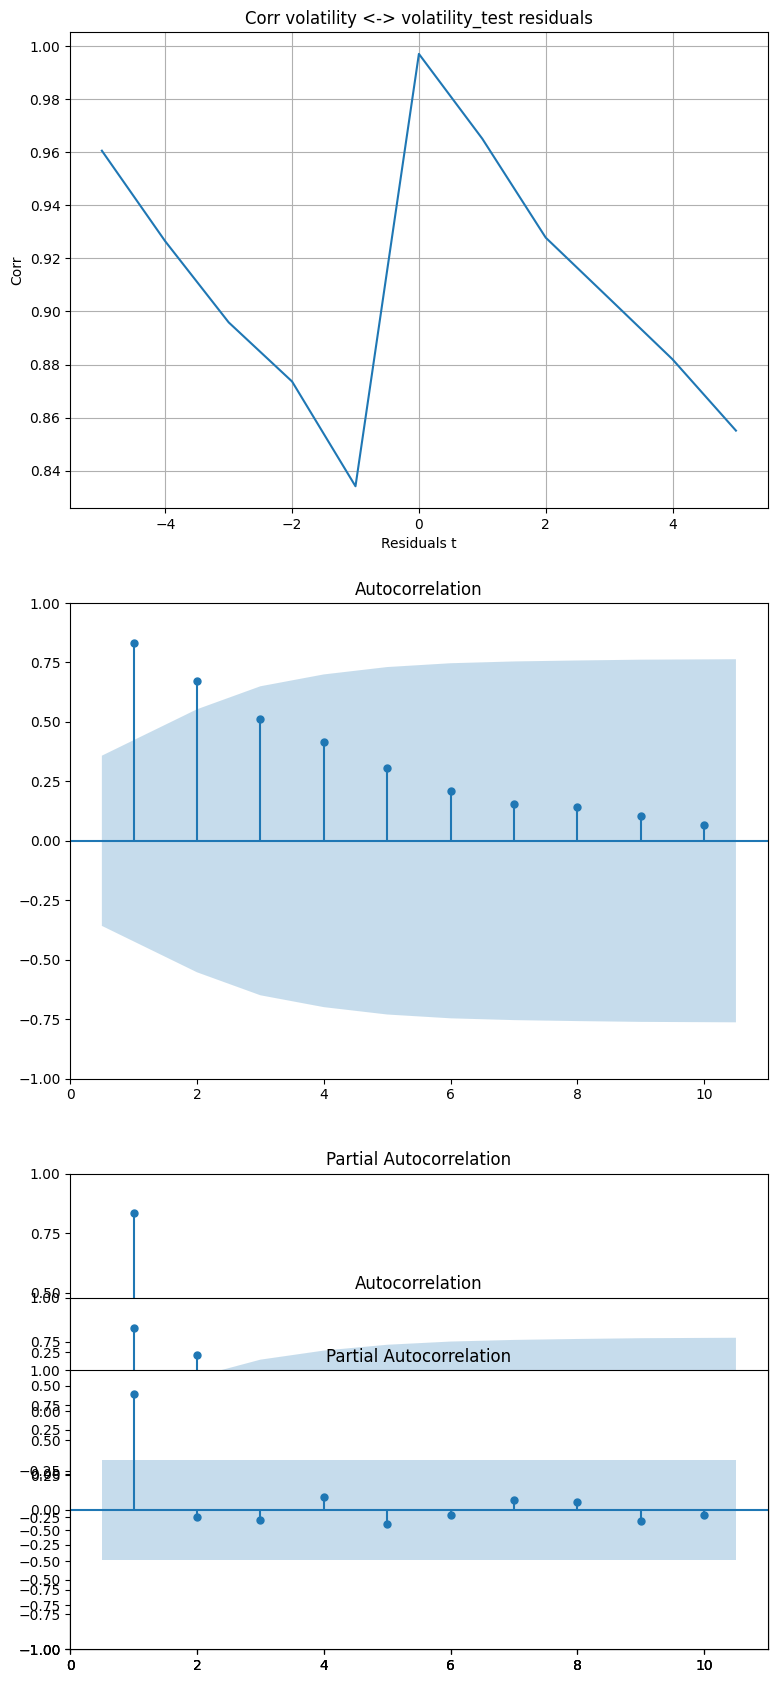

 96%|█████████▌| 5791444/6044636 [2:50:57<07:28, 564.63it/s]  


Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/Users/arseneducrocq/miniconda3/envs/py_env/lib/python3.11/site-packages/IPython/core/interactiveshell.py", line 3699, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/var/folders/tp/4k_p0hpx3tz149n0gc0sxh3r0000gn/T/ipykernel_16929/3361746753.py", line 29, in <module>
    analyse_volatility_residuals(model=volatility_model, buffer=buffer_train, volatility_sequence=volatility_sequence_train, scale=VOLATILITY_SCALE, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="volatility_train")
  File "/Users/arseneducrocq/Documents/intern-project/clustering-euronext-trades/src/analysis.py", line 113, in analyse_volatility_residuals
    residuals = get_volatility_residuals(model, buffer, categorical_col, scale)
                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/arseneducrocq/Documents/intern-project/clustering-euronext-trades/src/analysis.py", line 53, in get_volatility_residuals

In [18]:
from src.analysis import analyse_volatility_residuals
from src.volatility_nn import VolatilityPredictor
from src.config import VolatilityConfig

TRAIN_SIZE=0.95

volatility_config = VolatilityConfig(
    hidden_size=32, 
    activation=ReLU,
    dropout_rate=0.2
)


volatility_model = VolatilityPredictor(encoder_config=encoder_config, volatility_config=volatility_config)
volatility_model.load_weights("weight/volatility_model.safetensors")
mx.eval(volatility_model.parameters())

sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)

train_lenght = int(len(buffer)*TRAIN_SIZE)
buffer_train = dx.buffer_from_vector([buffer[i] for i in range(train_lenght)])
buffer_test = dx.buffer_from_vector([buffer[i] for i in range(train_lenght, len(buffer))])

volatility_sequence_train = mx.array([[float(buffer_train[i]["target"]), int(buffer_train[i]["categorical"][0, 1])]for i in range(len(buffer_train))], dtype=mx.float32)
volatility_sequence_test = mx.array([[float(buffer_test[i]["target"]), int(buffer_test[i]["categorical"][0, 1])] for i in range(len(buffer_test))], dtype=mx.float32)

analyse_volatility_residuals(model=volatility_model, buffer=buffer_test, volatility_sequence=volatility_sequence_test, scale=VOLATILITY_SCALE, categorical_col=CATEGORIAL_COLUMNS, save_fig = True, name="volatility_test")
analyse_volatility_residuals(model=volatility_model, buffer=buffer_train, volatility_sequence=volatility_sequence_train, scale=VOLATILITY_SCALE, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="volatility_train")


In [19]:
import importlib
import src.analysis
importlib.reload(src.analysis)
from src.analysis import plot_hook_path, get_volatility_model_activation, get_hook_similiarity

tree_activation = get_volatility_model_activation(model=volatility_model,
                                                  buffer=buffer_test,
                                                  categorical_col=CATEGORIAL_COLUMNS,
                                                  scale= VOLATILITY_SCALE)

score, avg_score = get_hook_similiarity(tree=tree_activation, top_layer=0.3)
print("avg score->", avg_score)
print("score->", score)

for isin in list(tree_activation.keys()):
    print(f"====FIGURE  {isin}====")
    plot_hook_path(tree_activation[isin])


 14%|█▍        | 45350/318139 [01:14<07:27, 609.11it/s] 


RuntimeError: [metal::malloc] Resource limit (499000) exceeded.

===========VAE MODEL===========

In [ ]:
#import importlib
#import src.vae
#importlib.reload(src.vae)
import time
from src.config import VAEConfig
from src.vae import VAE
from src.trainer import VAETrainer
from src.processing import get_vae_seq

vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

optim_vae_config = OptimizerConfig(
    optimizer_name="adamw", 
    lr = 1e-4
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
mx.eval(vae_model.parameters())

vae_sequence = get_vae_seq(data=dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
start = time.time()
vae_buffer = dx.buffer_from_vector(vae_sequence)
print('MLX buffer init in ', time.time() - start, "second")
vae_trainer = VAETrainer(model=vae_model, 
                         optim_config=optim_vae_config, 
                         buffer=vae_buffer, 
                         categorical_columns=CATEGORIAL_COLUMNS,
                         train_size=0.7, 
                         batch_size=1024) 

vae_trainer.epoch(n_epoch=10,
                  save_dir= SAVE_DIR,
                  model_name="vae",
                  plot_chart=True)


100%|██████████| 598/598 [00:17<00:00, 34.91it/s]


MLX buffer init in  27.671177864074707 second
MLX train buffer init in  15.911517858505249
MLX test buffer init in  8.679965734481812
EPOCH 1 --- 


4350it [57:30,  1.26it/s]
1865it [03:31,  8.81it/s]


TRAIN LOSS -178.1211420199515 ||| TEST LOSS -144.0472063079916
EPOCH 2 --- 


4350it [59:00,  1.23it/s]
1865it [03:52,  8.02it/s]


...

TRAIN LOSS -180.66470094176543 ||| TEST LOSS -144.07314792663738
EPOCH 8 --- 


4350it [1:07:21,  1.08it/s]
1865it [05:29,  5.65it/s]


TRAIN LOSS -180.66842719417878 ||| TEST LOSS -144.07596220369314
EPOCH 9 --- 


3133it [47:27,  1.10it/s]


KeyboardInterrupt: 

In [ ]:
from src.analysis import analyse_vae_residuals
from src.vae import VAE
from src.config import VAEConfig
from src.processing import get_vae_seq

vae_config = VAEConfig(
    compression_ratio=2.0,
    hidden_size=32,
    activation=ReLU,
    dropout_rate=0.2
)

vae_model = VAE(encoder_config=encoder_config, vae_config=vae_config)
vae_model = vae_model.load_weights("weight/vae.safetensors")
mx.eval(vae_model.parameters())
TRAIN_SIZE=0.7

sequence_data = get_volatility_seq(dataset, categorical_col=CATEGORIAL_COLUMNS, continous_col=CONTINUOUS_COLUMNS, sq_size=SEQUENCE_SIZE)
buffer = dx.buffer_from_vector(sequence_data)
train_lenght = int(len(buffer)*TRAIN_SIZE)
buffer_train = dx.buffer_from_vector([buffer[i] for i in range(train_lenght)])
buffer_test = dx.buffer_from_vector([buffer[i] for i in range(train_lenght, len(buffer))])

volatility_sequence_train = mx.array([float(buffer_train[i]["target"]) for i in range(len(buffer_train))], dtype=mx.float32)
volatility_sequence_test = mx.array([float(buffer_test[i]["target"]) for i in range(len(buffer_test))], dtype=mx.float32)

analyse_vae_residuals(model=vae_model, buffer=buffer_train, volatility_sequence=volatility_sequence_train, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="vae_train")
analyse_vae_residuals(model=vae_model, buffer=buffer_test, volatility_sequence=volatility_sequence_test, categorical_col=CATEGORIAL_COLUMNS,save_fig = True, name="vae_test")


100%|██████████| 598/598 [01:09<00:00,  8.63it/s]


Target mean -->  0.90912795 +/- 2.416408


ValueError: Slice indices must be integers or None.

==== Prediction Head without encoder pretrained ====

In [ ]:
from src.config import DiscreteConfig
from src.directional_nn import DiscreteHead
from src.trainer import DiscretizedVolTrainer
from src.processing import get_volatility_discretize_seq

directional_config = DiscreteConfig(
    num_states=3,
    hidden_size = 32,
    activation = ReLU,
    dropout_rate=0.2
)

directional_model = DiscreteHead(encoder_config=encoder_config, dir_config=directional_config)
mx.eval(directional_model.parameters())
directional_optim_config = OptimizerConfig(optimizer="adamw", lr=1e-4)

discrete_vol_sequence = get_volatility_discretize_seq(data=dataset, 
                                                      categorical_col=CATEGORIAL_COLUMNS, 
                                                      continous_col=CONTINUOUS_COLUMNS, 
                                                      sq_size= SEQUENCE_SIZE, 
                                                      n_states=3, 
                                                      fit_period=0.7)

discrete_buffer = dx.buffer_from_vector(discrete_vol_sequence)

directional_trainer= DiscretizedVolTrainer(model=directional_model, 
                                           optim_config=directional_optim_config, 
                                           buffer= discrete_buffer, 
                                           n_states=3, 
                                           train_size=0.7,
                                           batch_size=1024
                                           )
directional_trainer.epoch(n_epoch=5, save_dir=SAVE_DIR, model_name="no_pretrain_discrete_model", plot_chart=True)


In [ ]:
test = mx.random.normal(shape=(1000, ))
test.shape

(1000,)